# Analyze results from phyloglm

In [66]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

results_path = os.path.join(repo_root, "results")

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
loss_df = pd.read_csv(f"{results_path}/phyloglm_loss_qvals.csv", index_col="HOG")
dup_df = pd.read_csv(f"{results_path}/phyloglm_dup_qvals.csv", index_col="HOG")
continuous_df = pd.read_csv(f"{results_path}/phyloglm_continuous_qvals.csv", index_col="HOG")

In [68]:
loss_sig_pglm = loss_df[loss_df["qvalue"] < 0.05].sort_values("qvalue")
dup_sig_pglm = dup_df[dup_df["qvalue"] < 0.05].sort_values("qvalue")
continuous_sig_pglm = continuous_df[continuous_df["qvalue"] < 0.05].sort_values("qvalue")

print("Significant Loss HOGs by PhyloGLM:", loss_sig_pglm.shape[0])
print("Significant Duplication HOGs by PhyloGLM:", dup_sig_pglm.shape[0])
print("Significant Continuous HOGs by PhyloGLM:", continuous_sig_pglm.shape[0])

Significant Loss HOGs by PhyloGLM: 502
Significant Duplication HOGs by PhyloGLM: 23
Significant Continuous HOGs by PhyloGLM: 897


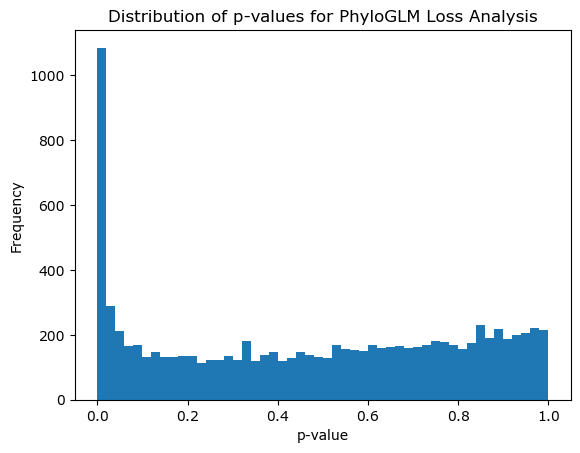

In [69]:
plt.hist(loss_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM Loss Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

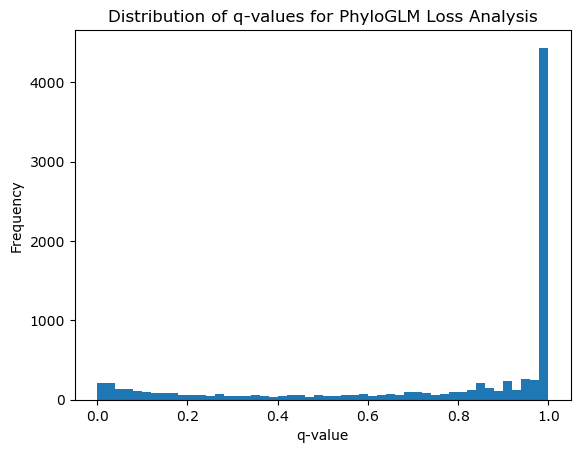

In [70]:
plt.hist(loss_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM Loss Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

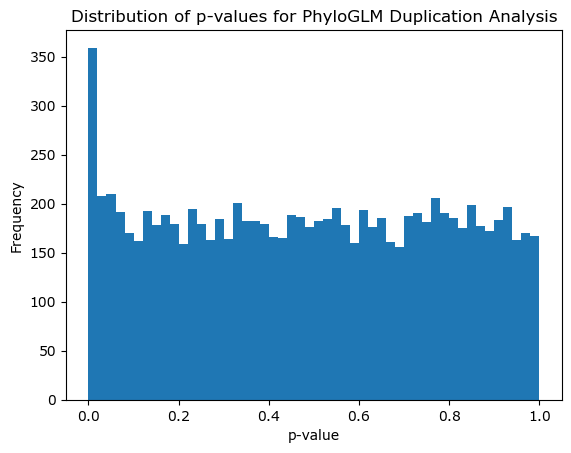

In [71]:
plt.hist(dup_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM Duplication Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

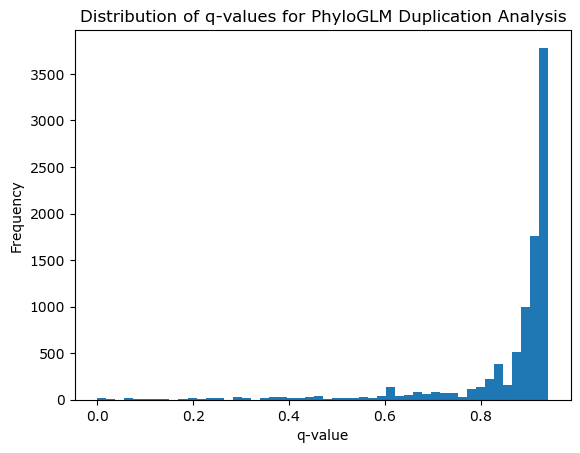

In [72]:
plt.hist(dup_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM Duplication Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

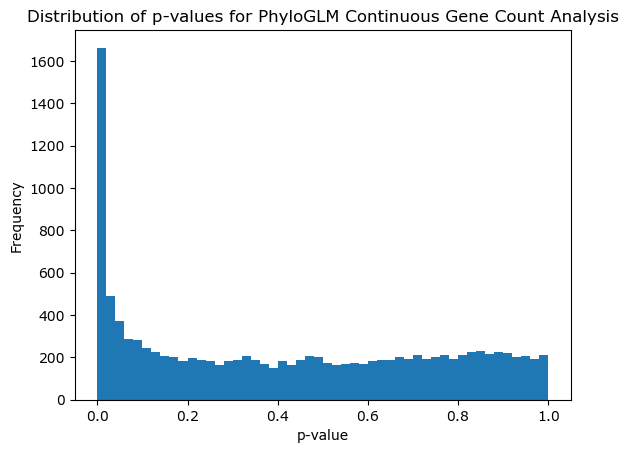

In [73]:
plt.hist(continuous_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM Continuous Gene Count Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

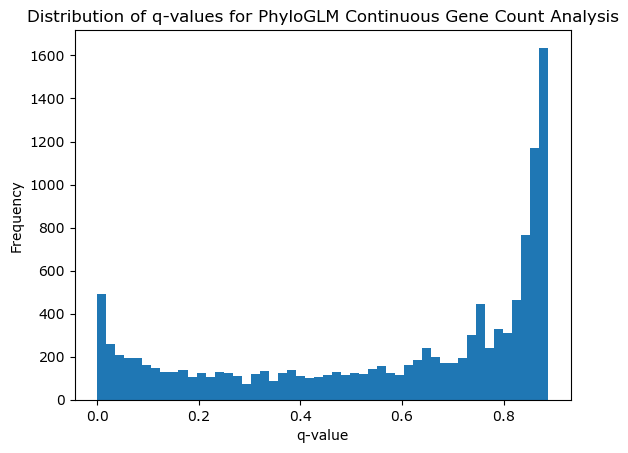

In [74]:
plt.hist(continuous_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM Continuous Gene Count Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

In [75]:
loss_res_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/perm_loss_pvalues.csv", index_col="HOG")
dup_res_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/perm_dup_pvalues.csv", index_col="HOG")

In [76]:
all_sig_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/fltrd_hits.csv", index_col="HOG")

In [77]:
loss_fg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("loss_fg", na=False)]
loss_bg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("loss_bg", na=False)]
dup_fg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("dup_fg", na=False)]
dup_bg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("dup_bg", na=False)]

print("Loss Foreground Significant by Permulation:", loss_fg_sig_perm.shape[0])
print("Loss Background Significant by Permulation:", loss_bg_sig_perm.shape[0])
print("Duplicate Foreground Significant by Permulation:", dup_fg_sig_perm.shape[0])
print("Duplicate Background Significant by Permulation:", dup_bg_sig_perm.shape[0])

Loss Foreground Significant by Permulation: 224
Loss Background Significant by Permulation: 529
Duplicate Foreground Significant by Permulation: 429
Duplicate Background Significant by Permulation: 383


In [78]:
loss_fg_sig_perm

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.288042,-0.281735,0.0038,0.9962,0.5328,0.4672,NaN,loss_fg
N5.HOG0001627,33,2.048043,-4.020457,0.0449,0.9551,0.9745,0.0253,", dup_bg","loss_fg, dup_bg"
N5.HOG0002072,52,3.473733,-0.762726,0.0108,0.9892,0.7989,0.2011,loss_fg,loss_fg
N5.HOG0002110,34,0.591760,-0.484782,0.0231,0.9769,0.8676,0.1324,NaN,loss_fg
N5.HOG0002648,31,1.918622,-2.243568,0.0114,0.9885,0.9204,0.0796,NaN,loss_fg
...,...,...,...,...,...,...,...,...,...
N5.HOG0072640,42,0.828993,-0.716336,0.0183,0.9817,0.7804,0.2196,NaN,loss_fg
N5.HOG0072641,42,0.647649,0.207193,0.0397,0.9603,0.3617,0.6383,NaN,loss_fg
N5.HOG0072753,41,1.106819,1.664557,0.0291,0.9709,0.2366,0.7630,NaN,loss_fg


In [79]:
loss_fg_sig_perm.sort_values("P-value loss more likely in fg").head()

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0034283,48,3.316114,-1.233371,0.0000,1.0000,0.7575,0.2424,loss_fg,loss_fg
N5.HOG0048549,61,4.353531,-1.561977,0.0001,0.9999,0.9176,0.0824,loss_fg,loss_fg
N5.HOG0047523,68,1.712740,-1.853517,0.0013,0.9987,0.9088,0.0911,NaN,loss_fg
N5.HOG0009549,30,1.804316,-3.015060,0.0014,0.9986,0.9255,0.0744,NaN,loss_fg
N5.HOG0030179,53,2.299431,-0.641408,0.0018,0.9982,0.7042,0.2958,NaN,loss_fg


In [80]:
loss_fg_sig_perm = loss_res_perm[loss_res_perm["pval_fg"] <= 0.05]
loss_bg_sig_perm = loss_res_perm[loss_res_perm["pval_bg"] <= 0.05]
dup_fg_sig_perm = dup_res_perm[dup_res_perm["pval_fg"] <= 0.05]
dup_bg_sig_perm = dup_res_perm[dup_res_perm["pval_bg"] <= 0.05]

print("Loss Foreground Significant by Permulation:", loss_fg_sig_perm.shape[0])
print("Loss Background Significant by Permulation:", loss_bg_sig_perm.shape[0])
print("Duplicate Foreground Significant by Permulation:", dup_fg_sig_perm.shape[0])
print("Duplicate Background Significant by Permulation:", dup_bg_sig_perm.shape[0])

Loss Foreground Significant by Permulation: 224
Loss Background Significant by Permulation: 529
Duplicate Foreground Significant by Permulation: 429
Duplicate Background Significant by Permulation: 383


In [81]:
loss_fg_sig_perm_thresh = loss_fg_sig_perm[loss_fg_sig_perm["Significant by avgd thresholds"].str.contains("loss_fg", na=False)].shape[0]
loss_bg_sig_perm_thresh = loss_bg_sig_perm[loss_bg_sig_perm["Significant by avgd thresholds"].str.contains("loss_bg", na=False)].shape[0]
dup_fg_sig_perm_thresh = dup_fg_sig_perm[dup_fg_sig_perm["Significant by avgd thresholds"].str.contains("dup_fg", na=False)].shape[0]
dup_bg_sig_perm_thresh = dup_bg_sig_perm[dup_bg_sig_perm["Significant by avgd thresholds"].str.contains("dup_bg", na=False)].shape[0]

print("Loss Foreground Significant by Permulation and Thresholds:", loss_fg_sig_perm_thresh)
print("Loss Background Significant by Permulation and Thresholds:", loss_bg_sig_perm_thresh)
print("Duplicate Foreground Significant by Permulation and Thresholds:", dup_fg_sig_perm_thresh)
print("Duplicate Background Significant by Permulation and Thresholds:", dup_bg_sig_perm_thresh)


KeyError: 'Significant by avgd thresholds'

In [ ]:
dup_fg_sig_pglm = dup_sig_pglm[dup_sig_pglm["coef_orb_weavingTRUE_Estimate"] > 0]
dup_bg_sig_pglm = dup_sig_pglm[dup_sig_pglm["coef_orb_weavingTRUE_Estimate"] < 0]
loss_fg_sig_pglm = loss_sig_pglm[loss_sig_pglm["coef_orb_weavingTRUE_Estimate"] > 0]
loss_bg_sig_pglm = loss_sig_pglm[loss_sig_pglm["coef_orb_weavingTRUE_Estimate"] < 0]

print("Duplication Foreground Significant by PhyloGLM (binary):", dup_fg_sig_pglm.shape[0])
print("Duplication Background Significant by PhyloGLM (binary):", dup_bg_sig_pglm.shape[0])
print("Loss Foreground Significant by PhyloGLM (binary):", loss_fg_sig_pglm.shape[0])
print("Loss Background Significant by PhyloGLM (binary):", loss_bg_sig_pglm.shape[0])

Duplication Foreground Significant by PhyloGLM (binary): 19
Duplication Background Significant by PhyloGLM (binary): 4
Loss Foreground Significant by PhyloGLM (binary): 291
Loss Background Significant by PhyloGLM (binary): 211


In [ ]:
continuous_sig_pglm_orb = continuous_sig_pglm[continuous_sig_pglm["coef_orb_weavingTRUE_Estimate"] > 0]
continuous_sig_pglm_nonorb = continuous_sig_pglm[continuous_sig_pglm["coef_orb_weavingTRUE_Estimate"] < 0]
print("Continuous Foreground Significant by PhyloGLM:", continuous_sig_pglm_orb.shape[0])
print("Continuous Background Significant by PhyloGLM:", continuous_sig_pglm_nonorb.shape[0])

Continuous Foreground Significant by PhyloGLM: 526
Continuous Background Significant by PhyloGLM: 371


In [ ]:
continuous_sig_pglm

,error,coef_.Intercept._Estimate,coef_.Intercept._StdErr,coef_.Intercept._z.value,coef_.Intercept._p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,qvalue
HOG,,,,,,,,,,
N5.HOG0062479,NaN,-0.134016,0.085759,-1.562710,0.118121,0.366769,0.054533,6.725679,1.747752e-11,1.839519e-07
N5.HOG0068302,NaN,-0.133468,0.091167,-1.463983,0.143199,0.361886,0.058008,6.238507,4.417655e-10,1.549870e-06
N5.HOG0058652,NaN,-2.399290,0.576015,-4.165324,0.000031,2.293797,0.364372,6.295210,3.069840e-10,1.549870e-06
N5.HOG0066470,NaN,-0.162799,0.134704,-1.208572,0.226827,0.509446,0.084547,6.025621,1.684613e-09,4.432663e-06
N5.HOG0057006,NaN,0.508036,0.135646,3.745300,0.000180,-0.834166,0.143385,-5.817649,5.968112e-09,1.256295e-05
...,...,...,...,...,...,...,...,...,...,...
N5.HOG0021726,NaN,-0.726651,0.539752,-1.346268,0.178216,0.984546,0.343982,2.862203,4.207068e-03,4.959337e-02
N5.HOG0060653,NaN,0.071594,0.192665,0.371596,0.710194,0.351214,0.122764,2.860890,4.224532e-03,4.967984e-02
N5.HOG0064737,NaN,0.205627,0.144185,1.426133,0.153830,-0.326817,0.114234,-2.860937,4.223915e-03,4.967984e-02


In [ ]:
loss_fg_sig_perm

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.288042,-0.281735,0.0038,0.9962,0.5328,0.4672,NaN,loss_fg
N5.HOG0001627,33,2.048043,-4.020457,0.0449,0.9551,0.9745,0.0253,", dup_bg","loss_fg, dup_bg"
N5.HOG0002072,52,3.473733,-0.762726,0.0108,0.9892,0.7989,0.2011,loss_fg,loss_fg
N5.HOG0002110,34,0.591760,-0.484782,0.0231,0.9769,0.8676,0.1324,NaN,loss_fg
N5.HOG0002648,31,1.918622,-2.243568,0.0114,0.9885,0.9204,0.0796,NaN,loss_fg
...,...,...,...,...,...,...,...,...,...
N5.HOG0072640,42,0.828993,-0.716336,0.0183,0.9817,0.7804,0.2196,NaN,loss_fg
N5.HOG0072641,42,0.647649,0.207193,0.0397,0.9603,0.3617,0.6383,NaN,loss_fg
N5.HOG0072753,41,1.106819,1.664557,0.0291,0.9709,0.2366,0.7630,NaN,loss_fg


In [ ]:
overlap_loss_fg_df = loss_fg_sig_perm.merge(continuous_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_loss_bg_df = loss_bg_sig_perm.merge(continuous_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_fg_df = dup_fg_sig_perm.merge(continuous_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_bg_df = dup_bg_sig_perm.merge(continuous_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))

print("Overlap Loss Foreground Significant by Both:", overlap_loss_fg_df.shape[0])
print("Overlap Loss Background Significant by Both:", overlap_loss_bg_df.shape[0])
print("Overlap Duplication Foreground Significant by Both:", overlap_dup_fg_df.shape[0])
print("Overlap Duplication Background Significant by Both:", overlap_dup_bg_df.shape[0])

Overlap Loss Foreground Significant by Both: 22
Overlap Loss Background Significant by Both: 56
Overlap Duplication Foreground Significant by Both: 71
Overlap Duplication Background Significant by Both: 81


In [ ]:
overlap_all_df = all_sig_perm.merge(continuous_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_all_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation,error,coef_.Intercept._Estimate,coef_.Intercept._StdErr,coef_.Intercept._z.value,coef_.Intercept._p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,qvalue
HOG,,,,,,,,,,,,,,,,,,,
N5.HOG0002298,30,-2.467858,1.155650,0.9909,0.0091,0.3621,0.6379,NaN,loss_bg,NaN,-1.719616,0.606574,-2.834967,0.004583,1.402103,0.407769,3.438473,0.000585,0.014122
N5.HOG0007085,78,-2.727537,-0.768582,0.9976,0.0024,0.7169,0.2831,NaN,loss_bg,NaN,-0.197156,0.318790,-0.618450,0.536279,0.607532,0.199406,3.046710,0.002314,0.033634
N5.HOG0007270,32,-2.655932,1.114187,0.9873,0.0127,0.3956,0.6044,NaN,loss_bg,NaN,-1.510297,0.656950,-2.298954,0.021508,1.506462,0.448481,3.359029,0.000782,0.017210
N5.HOG0007311,35,1.441096,-2.394613,0.0053,0.9947,0.9401,0.0599,NaN,loss_fg,NaN,-0.007673,0.305494,-0.025118,0.979961,-1.254252,0.422571,-2.968141,0.002996,0.039866
N5.HOG0007702,42,-2.870699,3.593198,0.9471,0.0529,0.0123,0.9877,dup_fg,dup_fg,NaN,-1.154932,0.454522,-2.540980,0.011054,0.998130,0.304527,3.277636,0.001047,0.020441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N5.HOG0071249,61,-2.992514,0.210530,0.9991,0.0009,0.3327,0.6671,loss_bg,loss_bg,NaN,-1.187833,0.512868,-2.316060,0.020555,0.966563,0.326275,2.962413,0.003052,0.040411
N5.HOG0071605,41,-1.494884,1.914310,0.9294,0.0706,0.0493,0.9507,NaN,dup_fg,NaN,-1.209264,0.662527,-1.825229,0.067966,1.392878,0.444787,3.131564,0.001739,0.028373
N5.HOG0071908,39,-1.683040,2.289244,0.9778,0.0222,0.0387,0.9613,", dup_fg","loss_bg, dup_fg",NaN,-0.562326,0.394157,-1.426654,0.153680,0.709980,0.246703,2.877875,0.004004,0.048074
